In [42]:
#此测试文件用于测试，离散形式k，f， 与连续形式k，f的输入是否对有限元结果有影响。
from typing import Sequence
from fealpy.backend import backend_manager as bm
from fealpy.backend import TensorLike

from fealpy.mesh import UniformMesh2d
from fealpy.functionspace.lagrange_fe_space import LagrangeFESpace
from fealpy.decorator import cartesian
from fealpy.fem import BilinearForm, ScalarDiffusionIntegrator
from fealpy.fem import LinearForm, ScalarSourceIntegrator
from fealpy.fem import DirichletBC
from fealpy.solver import cg

device = 'cpu'
bm.set_backend('pytorch')
bm.set_default_device(device)

In [43]:
class MixedFrequencyPDE:
    def __init__(self):
        self.domain = [0, 1, 0, 1]

    @cartesian
    def solution(self, p: TensorLike) -> TensorLike:
        x = p[..., 0]
        y = p[..., 1]
        pi = bm.pi

        return (
            bm.sin(pi*x) * bm.sin(pi*y)
            + 0.25 * bm.sin(3*pi*x) * bm.sin(2*pi*y)
        )

    @cartesian
    def diffusion_coef(self, p: TensorLike) -> TensorLike:
        x = p[..., 0]
        y = p[..., 1]
        pi = bm.pi
        return 2.0 + 0.5 * bm.sin(2*pi*x) * bm.sin(2*pi*y)

    @cartesian
    def source(self, p: TensorLike) -> TensorLike:
        x = p[..., 0]
        y = p[..., 1]
        pi = bm.pi

        u1 = bm.sin(pi*x) * bm.sin(pi*y)
        u2 = 0.25 * bm.sin(3*pi*x) * bm.sin(2*pi*y)
        u = u1 + u2

        ux = (
            pi * bm.cos(pi*x) * bm.sin(pi*y)
            + 0.25 * 3*pi * bm.cos(3*pi*x) * bm.sin(2*pi*y)
        )
        uy = (
            pi * bm.sin(pi*x) * bm.cos(pi*y)
            + 0.25 * 2*pi * bm.sin(3*pi*x) * bm.cos(2*pi*y)
        )

        uxx = (
            -pi**2 * u1
            - 0.25 * (3*pi)**2 * bm.sin(3*pi*x) * bm.sin(2*pi*y)
        )
        uyy = (
            -pi**2 * u1
            - 0.25 * (2*pi)**2 * bm.sin(3*pi*x) * bm.sin(2*pi*y)
        )

        k = 2.0 + 0.5 * bm.sin(2*pi*x) * bm.sin(2*pi*y)
        kx = 0.5 * 2*pi * bm.cos(2*pi*x) * bm.sin(2*pi*y)
        ky = 0.5 * 2*pi * bm.sin(2*pi*x) * bm.cos(2*pi*y)

        return -(kx*ux + ky*uy + k*(uxx + uyy))

    @cartesian
    def dirichlet(self, p: TensorLike) -> TensorLike:
        return self.solution(p)

In [44]:
import sys
import time
import numpy as np
import torch
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import Delaunay

sys.path.append(r"C:\git-workplace\HeatSim\HypridMethod")

from gauss_seidel_only import gauss_seidel_only, as_csr_matrix, to_numpy_vector
from hybrid_gs_mionet import hybrid_gs_mionet


def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    if hasattr(x, "cpu") and hasattr(x.cpu(), "numpy"):
        return x.cpu().numpy()
    if hasattr(x, "numpy"):
        return x.numpy()
    return np.asarray(x)

In [45]:
rtol = 1e-1

In [46]:
PDE = MixedFrequencyPDE()

domain = PDE.domain
nx, ny = 400, 400

hx = (domain[1] - domain[0])/nx
hy = (domain[3] - domain[2])/ny

mesh = UniformMesh2d((0, nx, 0, ny), h=(hx, hy), origin=(domain[0], domain[2]), ftype=bm.float32)

cqf = mesh.quadrature_formula(4, 'cell')
bcs, ws = cqf.get_quadrature_points_and_weights()
ps = mesh.bc_to_point(bcs)

space= LagrangeFESpace(mesh, p=1)
uh = space.function()
bform = BilinearForm(space)
DI = ScalarDiffusionIntegrator(PDE.diffusion_coef(ps))
bform.add_integrator(DI)

lform = LinearForm(space)
SI = ScalarSourceIntegrator(PDE.source(ps))
lform.add_integrator(SI)

A = bform.assembly()
F = lform.assembly()

A, F = DirichletBC(space, gd=PDE.solution).apply(A, F)


In [47]:
uh_cg = cg(A,F)

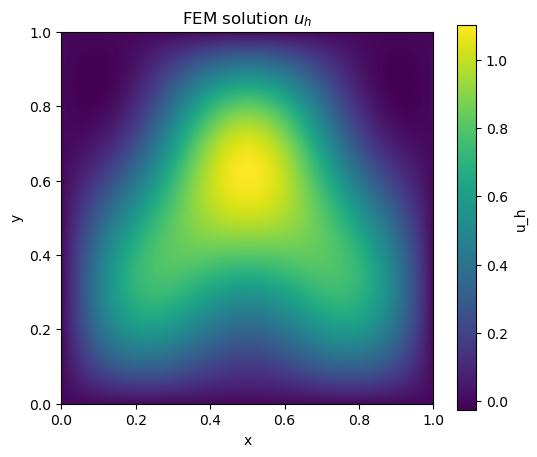

In [48]:
import matplotlib.pyplot as plt

uh_true_solver = uh_cg.reshape(nx + 1, ny + 1)

plt.figure(figsize=(6, 5))
plt.imshow(
    uh_true_solver.T,              # 转置一下，让 x/y 方向显示更自然
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal"
)
plt.colorbar(label="u_h")
plt.xlabel("x")
plt.ylabel("y")
plt.title("FEM solution $u_h$")
plt.show()

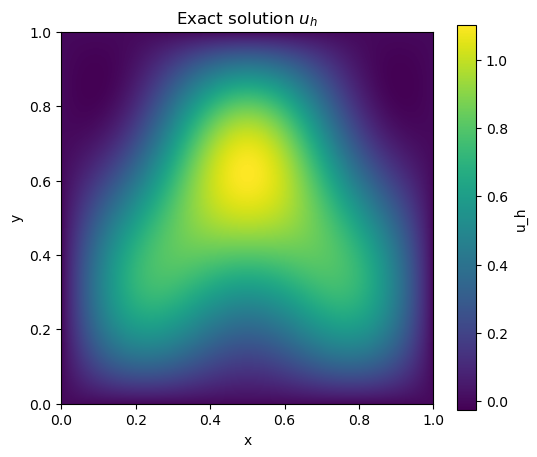

In [49]:
import matplotlib.pyplot as plt

uh_true_solver = PDE.solution(mesh.node).reshape(nx + 1, ny + 1)

plt.figure(figsize=(6, 5))
plt.imshow(
    uh_true_solver.T,              # 转置一下，让 x/y 方向显示更自然
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal"
)
plt.colorbar(label="u_h")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Exact solution $u_h$")
plt.show()

In [50]:
def make_residual_to_sensor_lumped(
    *,
    node_coords,
    sensor_points,
    nx,
    ny,
    domain=(0.0, 1.0, 0.0, 1.0),
    boundary_dof=None,
    dtype=np.float32,
):
    node_coords = np.asarray(node_coords, dtype=np.float64)
    sensor_points = np.asarray(sensor_points, dtype=np.float64)

    ndof = node_coords.shape[0]

    x0, x1, y0, y1 = domain
    hx = (x1 - x0) / nx
    hy = (y1 - y0) / ny

    # lumped mass 近似：把 FEM 残差向量转成残差函数节点值
    mass_lumped = np.full(ndof, hx * hy, dtype=np.float64)

    x = node_coords[:, 0]
    y = node_coords[:, 1]

    on_left = np.isclose(x, x0)
    on_right = np.isclose(x, x1)
    on_bottom = np.isclose(y, y0)
    on_top = np.isclose(y, y1)

    on_boundary = on_left | on_right | on_bottom | on_top
    on_corner = (on_left | on_right) & (on_bottom | on_top)

    mass_lumped[on_boundary] *= 0.5
    mass_lumped[on_corner] *= 0.5

    if boundary_dof is not None:
        boundary_dof = np.asarray(boundary_dof, dtype=bool)

    # 预先构造剖分，避免每次 correction 重复做 Delaunay
    tri = Delaunay(node_coords)

    def residual_to_sensor(r):
        r = to_numpy(r).reshape(-1).astype(np.float64)

        if r.shape[0] != ndof:
            raise ValueError(f"r length {r.shape[0]} does not match ndof {ndof}")

        q_node = r / mass_lumped

        if boundary_dof is not None:
            q_node[boundary_dof] = 0.0

        interp = LinearNDInterpolator(tri, q_node, fill_value=0.0)
        r_sensor = interp(sensor_points)

        return np.asarray(r_sensor, dtype=dtype)

    return residual_to_sensor

In [51]:
node_coords = to_numpy(mesh.node).astype(np.float32)
u_exact = to_numpy(PDE.solution(mesh.node)).reshape(-1).astype(np.float64)

boundary_dof = to_numpy(space.is_boundary_dof()).astype(bool)

print("node_coords:", node_coords.shape)
print("u_exact:", u_exact.shape)
print("boundary_dof:", boundary_dof.shape)

node_coords: (160801, 2)
u_exact: (160801,)
boundary_dof: (160801,)


In [52]:
t0 = time.perf_counter()

x_gs, info_gs = gauss_seidel_only(
    A,
    F,
    maxiter=100000,
    rtol=rtol,
    atol=0.0,
    check_every=100,
    verbose=True,
)

time_gs = time.perf_counter() - t0

err_gs = np.linalg.norm(x_gs - u_exact) / np.linalg.norm(u_exact)

print("========== Pure GS ==========")
print("converged:", info_gs["converged"])
print("num_iter:", info_gs["num_iter"])
print("rel_res:", info_gs["rel_res"])
print("time:", time_gs)
print("relative true error:", err_gs)

GS iter=0, rel_res=1.000000e+00, abs_res=9.562381e-02
GS iter=100, rel_res=9.526185e-01, abs_res=9.109301e-02
GS iter=200, rel_res=9.096925e-01, abs_res=8.698826e-02
GS iter=300, rel_res=8.700123e-01, abs_res=8.319389e-02
GS iter=400, rel_res=8.332308e-01, abs_res=7.967670e-02
GS iter=500, rel_res=7.990966e-01, abs_res=7.641266e-02
GS iter=600, rel_res=7.674010e-01, abs_res=7.338180e-02
GS iter=700, rel_res=7.379611e-01, abs_res=7.056665e-02
GS iter=800, rel_res=7.106119e-01, abs_res=6.795141e-02
GS iter=900, rel_res=6.852024e-01, abs_res=6.552166e-02
GS iter=1000, rel_res=6.615929e-01, abs_res=6.326403e-02
GS iter=1100, rel_res=6.396533e-01, abs_res=6.116608e-02
GS iter=1200, rel_res=6.192622e-01, abs_res=5.921621e-02
GS iter=1300, rel_res=6.003058e-01, abs_res=5.740353e-02
GS iter=1400, rel_res=5.826775e-01, abs_res=5.571784e-02
GS iter=1500, rel_res=5.662774e-01, abs_res=5.414960e-02
GS iter=1600, rel_res=5.510115e-01, abs_res=5.268982e-02
GS iter=1700, rel_res=5.367922e-01, abs_res

In [53]:
data_dir = r"C:\git-workplace\HeatSim\HypridMethod\Data\data\mionet_gp_2d_5000"

sensor_points = np.load(data_dir + r"\sensor_points.npy").astype(np.float32)

sx = sensor_points[:, 0]
sy = sensor_points[:, 1]

k_sensor_test = (
    2.0 + 0.5 * np.sin(2*np.pi*sx) * np.sin(2*np.pi*sy)
).astype(np.float32)
print("sensor_points:", sensor_points.shape)
print("k_sensor_test:", k_sensor_test.shape)
print("k range:", k_sensor_test.min(), k_sensor_test.max())

sensor_points: (10000, 2)
k_sensor_test: (10000,)
k range: 1.5001259 2.499874


In [54]:
residual_to_sensor = make_residual_to_sensor_lumped(
    node_coords=node_coords,
    sensor_points=sensor_points,
    nx=nx,
    ny=ny,
    domain=(0.0, 1.0, 0.0, 1.0),
    boundary_dof=boundary_dof,
    dtype=np.float32,
)

In [55]:
import sys
import numpy as np
import torch
from torch import nn

# 你的脚本所在目录
sys.path.append(r"C:\git-workplace\HeatSim\HypridMethod")

from mionet_linear import LinearMIONet, MIONetConfig

# 1. 路径
data_dir = r"C:\git-workplace\HeatSim\HypridMethod\Data\data\mionet_gp_2d_5000"
# ckpt_path = r"C:\git-workplace\HeatSim\HypridMethod\Train1\best.pt"
ckpt_path = r"C:\git-workplace\HeatSim\HypridMethod\mionet_ckpt\last.pt"

# 2. 读取数据形状，用来确定 k_dim 和 f_dim
k_sensor = np.load(data_dir + r"\k_sensor.npy", mmap_mode="r")
f_sensor = np.load(data_dir + r"\f_sensor.npy", mmap_mode="r")
output_points = np.load(data_dir + r"\output_points.npy")

k_dim = k_sensor.shape[1]
f_dim = f_sensor.shape[1]

print("k_dim:", k_dim)
print("f_dim:", f_dim)
print("output_points:", output_points.shape)


# 3. 重新创建和训练时一样的模型
cfg = MIONetConfig(
    k_dim=k_dim,
    f_dim=f_dim,
    coord_dim=2,
    latent_dim=500,
    k_hidden=(500, 500, 500),
    trunk_hidden=(500, 500, 500),
    activation=nn.Tanh,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LinearMIONet(cfg).to(device)


# 4. 读取 best.pt
ckpt = torch.load(ckpt_path, map_location=device)

print("checkpoint keys:", ckpt.keys())
print("best epoch:", ckpt["epoch"])
print("metrics:", ckpt["metrics"])


# 5. 加载最优模型参数
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("best.pt loaded successfully.")


k_dim: 10000
f_dim: 10000
output_points: (10201, 2)
checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'config', 'metrics'])
best epoch: 2000
metrics: {'best_val_rel_l2': 0.13839492127299308}
best.pt loaded successfully.


C:\Users\Rainbow\AppData\Local\Temp\ipykernel_28860\3440275408.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


In [56]:
node_coords = to_numpy(mesh.node).astype(np.float32)
output_coords = node_coords

In [57]:
t0 = time.perf_counter()



x_hybrid, info_hybrid = hybrid_gs_mionet(
    A.to_scipy(),
    F,
    model=model,
    k_sensor=k_sensor_test,
    output_coords=output_coords,
    residual_to_sensor=residual_to_sensor,
    correction_period=1600,
    maxiter=100000,
    rtol=rtol,
    atol=0.0,
    check_every=100,
    correction_scale=0.5,   # 建议先用 0.5，更稳；稳定后可以改成 1.0
    device=str(device),
    dtype=torch.float32,
    verbose=True,
)

time_hybrid = time.perf_counter() - t0

err_hybrid = np.linalg.norm(x_hybrid - u_exact) / np.linalg.norm(u_exact)

print("========== GS-MIONet ==========")
print("converged:", info_hybrid["converged"])
print("num_iter:", info_hybrid["num_iter"])
print("rel_res:", info_hybrid["rel_res"])
print("time:", time_hybrid)
print("relative true error:", err_hybrid)
print("correction_iters:", info_hybrid["correction_iters"][:10])

iter=0, rel_res=1.000000e+00, abs_res=9.562381e-02
iter=100, rel_res=9.526185e-01, abs_res=9.109301e-02
iter=200, rel_res=9.096925e-01, abs_res=8.698826e-02
iter=300, rel_res=8.700123e-01, abs_res=8.319389e-02
iter=400, rel_res=8.332308e-01, abs_res=7.967670e-02
iter=500, rel_res=7.990966e-01, abs_res=7.641266e-02
iter=600, rel_res=7.674010e-01, abs_res=7.338180e-02
iter=700, rel_res=7.379611e-01, abs_res=7.056665e-02
iter=800, rel_res=7.106119e-01, abs_res=6.795141e-02
iter=900, rel_res=6.852024e-01, abs_res=6.552166e-02
iter=1000, rel_res=6.615929e-01, abs_res=6.326403e-02
iter=1100, rel_res=6.396533e-01, abs_res=6.116608e-02
iter=1200, rel_res=6.192622e-01, abs_res=5.921621e-02
iter=1300, rel_res=6.003058e-01, abs_res=5.740353e-02
iter=1400, rel_res=5.826775e-01, abs_res=5.571784e-02
iter=1500, rel_res=5.662774e-01, abs_res=5.414960e-02
iter=1600 corrected, rel_res=2.065095e+01, abs_res=1.974723e+00
iter=1700, rel_res=2.715995e-01, abs_res=2.597138e-02
iter=1800, rel_res=1.883254e-0

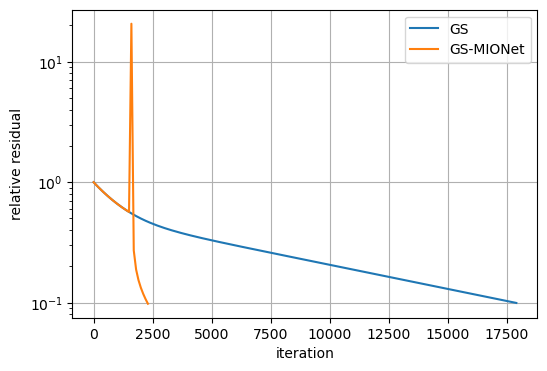

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.semilogy(np.arange(len(info_gs["history"])) * 100, info_gs["history"], label="GS")
plt.semilogy(np.arange(len(info_hybrid["history"])) * 100, info_hybrid["history"], label="GS-MIONet")

plt.xlabel("iteration")
plt.ylabel("relative residual")
plt.legend()
plt.grid(True)
plt.show()

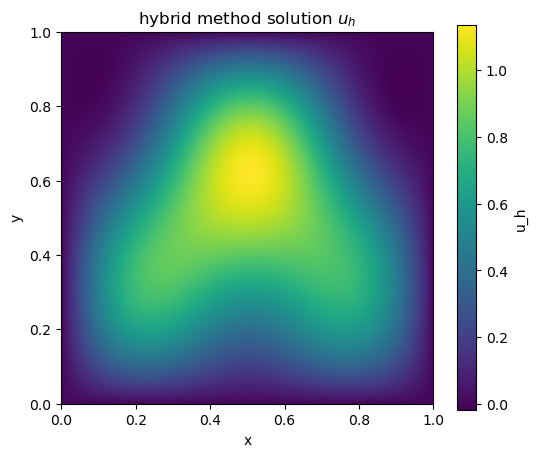

In [59]:
import matplotlib.pyplot as plt

uh_2d = x_hybrid.reshape(nx + 1, ny + 1)

plt.figure(figsize=(6, 5))
plt.imshow(
    uh_2d.T,              # 转置一下，让 x/y 方向显示更自然
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal"
)
plt.colorbar(label="u_h")
plt.xlabel("x")
plt.ylabel("y")
plt.title("hybrid method solution $u_h$")
plt.show()

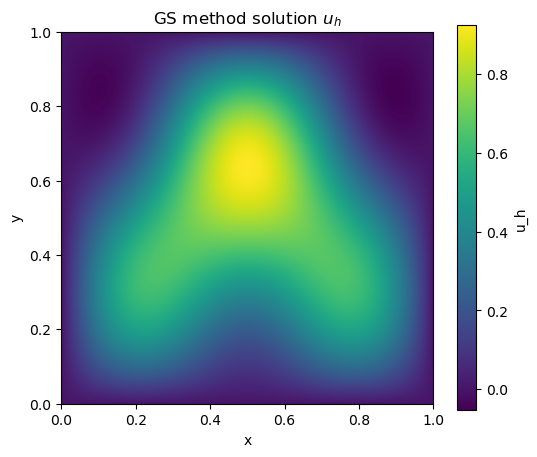

In [60]:
import matplotlib.pyplot as plt

uh_2d = x_gs.reshape(nx + 1, ny + 1)

plt.figure(figsize=(6, 5))
plt.imshow(
    uh_2d.T,              # 转置一下，让 x/y 方向显示更自然
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal"
)
plt.colorbar(label="u_h")
plt.xlabel("x")
plt.ylabel("y")
plt.title("GS method solution $u_h$")
plt.show()

In [61]:
print("========== Comparison ==========")
print(f"{'method':<12} {'iter':>10} {'rel_res':>14} {'true_err':>14} {'time(s)':>12}")
print("-" * 70)

print(
    f"{'GS':<12} "
    f"{info_gs['num_iter']:>10d} "
    f"{info_gs['rel_res']:>14.4e} "
    f"{err_gs:>14.4e} "
    f"{time_gs:>12.3f}"
)

print(
    f"{'GS-MIONet':<12} "
    f"{info_hybrid['num_iter']:>10d} "
    f"{info_hybrid['rel_res']:>14.4e} "
    f"{err_hybrid:>14.4e} "
    f"{time_hybrid:>12.3f}"
)

========== Comparison ==========
method             iter        rel_res       true_err      time(s)
----------------------------------------------------------------------
GS                17900     9.9550e-02     1.8572e-01      409.664
GS-MIONet          2300     9.8080e-02     5.7695e-02       68.263
